In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/Colab Notebooks/ML"

Mounted at /content/drive


In [ ]:
!pip install mup

  Preparing metadata (setup.py) ... done
  Created wheel for mup: filename=mup-1.0.0-py3-none-any.whl size=23629 sha256=1b0901f3ca35c14a202ded286d4605ac652fb18e8decca6480acd248a26b5b02
  Stored in directory: /root/.cache/pip/wheels/05/d2/b3/6c9337d770160e18d95735f139be998987fd43a23fb8126dfb
Successfully built mup


In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import random, math, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from mup import MuReadout, set_base_shapes, MuAdamW
from tokenizers import Tokenizer

In [ ]:
tokenizer   = Tokenizer.from_file(base_path + "/svg_tokenizer.json")
train_tokens = torch.load(base_path + "/train_tokens.pt")
val_tokens   = torch.load(base_path + "/val_tokens.pt")
test_tokens  = torch.load(base_path + "/test_tokens.pt")

print("Vocab size:", tokenizer.get_vocab_size())
print("Train tokens:", sum(len(x) for x in train_tokens))

Vocab size: 4000
Train tokens: 130335440


In [ ]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0

        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.n_head  = config.n_head
        self.dropout = nn.Dropout(config.dropout)

        self.register_buffer(
            "bias",
            torch.tril(torch.ones(config.block_size, config.block_size))
            .view(1, 1, config.block_size, config.block_size)
        )

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(C, dim=2)

        head_size = C // self.n_head
        q = q.view(B, T, self.n_head, head_size).transpose(1, 2)
        k = k.view(B, T, self.n_head, head_size).transpose(1, 2)
        v = v.view(B, T, self.n_head, head_size).transpose(1, 2)

        # µP attention scaling: 1/d instead of 1/sqrt(d)
        att = (q @ k.transpose(-2, -1)) / head_size
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)

        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1  = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln2  = nn.LayerNorm(config.n_embd)
        self.mlp  = nn.Sequential(
            nn.Linear(config.n_embd, config.ff_mult * config.n_embd),
            nn.GELU(),
            nn.Linear(config.ff_mult * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.tok_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.blocks  = nn.Sequential(*[Block(config) for _ in range(config.n_layer)])
        self.ln_f    = nn.LayerNorm(config.n_embd)
        self.head    = MuReadout(config.n_embd, config.vocab_size)   # µP output layer

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos  = torch.arange(0, T, device=idx.device)
        x    = self.tok_emb(idx) + self.pos_emb(pos)[None, :, :]
        x    = self.blocks(x)
        x    = self.ln_f(x)
        logits = self.head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

In [ ]:
class ModelConfig:
    def __init__(self, d_model, n_layer, n_head):
        self.block_size = 256
        self.vocab_size = 4000
        self.n_embd  = d_model
        self.n_layer = n_layer
        self.n_head  = n_head
        self.dropout = 0.1
        self.ff_mult = 4

In [ ]:
model_configs = {
    "tiny":   ModelConfig(128, 6, 4),
    "small":  ModelConfig(192, 6, 6),
    "medium": ModelConfig(384, 6, 6),
    "large":  ModelConfig(512, 6, 8),
    "xl":     ModelConfig(768, 6, 12),
}

In [ ]:
base_config  = model_configs["tiny"]
delta_config = ModelConfig(192, 6, 6)

base_model  = GPT(base_config)
delta_model = GPT(delta_config)

In [ ]:
def get_batch(tokens, batch_size, block_size):
    x = torch.zeros((batch_size, block_size), dtype=torch.long)
    y = torch.zeros((batch_size, block_size), dtype=torch.long)
    for i in range(batch_size):
        doc = random.choice(tokens)
        while len(doc) <= block_size + 1:
            doc = random.choice(tokens)
        start = random.randint(0, len(doc) - block_size - 1)
        chunk = doc[start:start + block_size + 1]
        x[i] = torch.tensor(chunk[:-1])
        y[i] = torch.tensor(chunk[1:])
    return x, y


@torch.no_grad()
def evaluate(model, val_tokens, config, steps=50):
    device = next(model.parameters()).device
    model.eval()
    losses = []
    for _ in range(steps):
        x, y = get_batch(val_tokens, 16, config.block_size)
        x, y = x.to(device), y.to(device)
        _, loss = model(x, y)
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)


def get_lr(step, max_steps, base_lr, warmup_steps):
    if step < warmup_steps:
        return base_lr * step / warmup_steps
    progress = (step - warmup_steps) / (max_steps - warmup_steps)
    return base_lr * 0.5 * (1 + math.cos(math.pi * progress))

In [ ]:
def train_tiny_mup_lr(lr, train_tokens, val_tokens, config):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = GPT(config)
    set_base_shapes(model, base_model, delta=delta_model)
    model = model.to(device)

    optimizer = MuAdamW(model.parameters(), lr=lr, weight_decay=0.1)

    steps        = 2000
    warmup_steps = int(0.1 * steps)
    val_history  = []

    for step in range(steps):
        cur_lr = get_lr(step, steps, lr, warmup_steps)
        for pg in optimizer.param_groups:
            pg['lr'] = cur_lr

        x, y = get_batch(train_tokens, 32, config.block_size)
        x, y = x.to(device), y.to(device)

        _, loss = model(x, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 200 == 0:
            val_loss = evaluate(model, val_tokens, config)
            val_history.append(val_loss)
            print(f"[µP] LR {lr:.1e} | step {step} | val {val_loss:.4f}")

    final_val = evaluate(model, val_tokens, config)
    return final_val, val_history


config = model_configs["tiny"]
lrs    = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 5e-3]

results_mup_lr = {}
for lr in lrs:
    print(f"\n{'='*20}\nTesting µP LR: {lr}")
    val_loss, curve = train_tiny_mup_lr(lr, train_tokens, val_tokens, config)
    results_mup_lr[lr] = (val_loss, curve)

best_mup_lr = min(results_mup_lr, key=lambda x: results_mup_lr[x][0])
print("\nBEST µP LR:", best_mup_lr)

lrs_sorted   = sorted(results_mup_lr.keys())
final_losses = [results_mup_lr[lr][0] for lr in lrs_sorted]


Testing µP LR: 1e-05
[µP] LR 1.0e-05 | step 0 | val 8.5001
[µP] LR 1.0e-05 | step 200 | val 7.5808
[µP] LR 1.0e-05 | step 400 | val 6.1698
[µP] LR 1.0e-05 | step 600 | val 5.5646
[µP] LR 1.0e-05 | step 800 | val 5.1169
[µP] LR 1.0e-05 | step 1000 | val 4.7992
[µP] LR 1.0e-05 | step 1200 | val 4.5846
[µP] LR 1.0e-05 | step 1400 | val 4.4620
[µP] LR 1.0e-05 | step 1600 | val 4.3694
[µP] LR 1.0e-05 | step 1800 | val 4.3603

Testing µP LR: 3e-05
[µP] LR 3.0e-05 | step 0 | val 8.4997
[µP] LR 3.0e-05 | step 200 | val 6.0720
[µP] LR 3.0e-05 | step 400 | val 4.5078
[µP] LR 3.0e-05 | step 600 | val 3.5747
[µP] LR 3.0e-05 | step 800 | val 2.9549
[µP] LR 3.0e-05 | step 1000 | val 2.6265
[µP] LR 3.0e-05 | step 1200 | val 2.4292
[µP] LR 3.0e-05 | step 1400 | val 2.3419
[µP] LR 3.0e-05 | step 1600 | val 2.2915
[µP] LR 3.0e-05 | step 1800 | val 2.2720

Testing µP LR: 0.0001
[µP] LR 1.0e-04 | step 0 | val 8.4465
[µP] LR 1.0e-04 | step 200 | val 4.1822
[µP] LR 1.0e-04 | step 400 | val 2.2943
[µP] LR 1

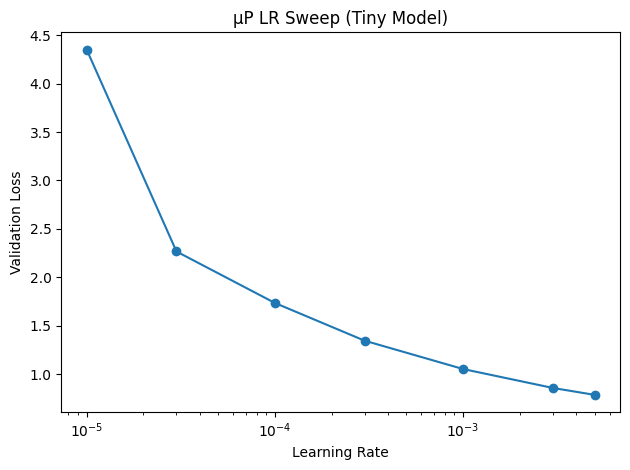

In [ ]:
plt.figure()
plt.xscale("log")
plt.plot(lrs_sorted, final_losses, marker="o")
plt.xlabel("Learning Rate")
plt.ylabel("Validation Loss")
plt.title("µP LR Sweep (Tiny Model)")
plt.tight_layout()
plt.show()

In [ ]:
def train_model(name, config, train_tokens, val_tokens, lr):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = GPT(config)
    set_base_shapes(model, base_model, delta=delta_model)
    model = model.to(device)

    optimizer = MuAdamW(model.parameters(), lr=lr, weight_decay=0.1)

    batch_size       = 32
    block_size       = config.block_size
    tokens_per_step  = batch_size * block_size
    total_tokens     = sum(len(x) for x in train_tokens)
    steps            = total_tokens // tokens_per_step
    warmup_steps     = int(0.05 * steps)

    print(f"\n{name}: {steps} steps (1 epoch)")

    train_losses = []
    val_losses   = []

    if device == "cuda":
        torch.cuda.reset_peak_memory_stats()

    start = time.time()

    for step in range(steps):
        cur_lr = get_lr(step, steps, lr, warmup_steps)
        for pg in optimizer.param_groups:
            pg['lr'] = cur_lr

        x, y = get_batch(train_tokens, batch_size, block_size)
        x, y = x.to(device), y.to(device)

        _, loss = model(x, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        if step % 500 == 0:
            val_loss = evaluate(model, val_tokens, config)
            val_losses.append(val_loss)
            print(f"{name} | step {step}/{steps} | val {val_loss:.4f}")

    end = time.time()

    epoch_time       = end - start
    tokens_processed = steps * tokens_per_step
    throughput       = tokens_processed / epoch_time
    max_mem          = torch.cuda.max_memory_allocated() / 1e9 if device == "cuda" else 0

    final_val = evaluate(model, val_tokens, config)
    print(f"{name} | FINAL val {final_val:.4f} | time {epoch_time:.1f}s | "
          f"tok/s {throughput:.0f} | mem {max_mem:.2f}GB")

    result = {
        "params":       sum(p.numel() for p in model.parameters()),
        "final_val":    final_val,
        "train_losses": train_losses,
        "val_losses":   val_losses,
        "time":         epoch_time,
        "throughput":   throughput,
        "memory":       max_mem,
    }
    torch.save(result, base_path + f"/mup_{name}_result.pt")
    return result

In [ ]:
temp_tiny = train_model("tiny", model_configs["tiny"], train_tokens, val_tokens, best_mup_lr)


tiny: 15910 steps (1 epoch)
tiny | step 0/15910 | val 8.3909
tiny | step 500/15910 | val 1.2811
tiny | step 1000/15910 | val 0.9420
tiny | step 1500/15910 | val 0.8303
tiny | step 2000/15910 | val 0.7870
tiny | step 2500/15910 | val 0.7509
tiny | step 3000/15910 | val 0.7326
tiny | step 3500/15910 | val 0.6983
tiny | step 4000/15910 | val 0.7006
tiny | step 4500/15910 | val 0.6835
tiny | step 5000/15910 | val 0.6666
tiny | step 5500/15910 | val 0.6490
tiny | step 6000/15910 | val 0.6311
tiny | step 6500/15910 | val 0.6355
tiny | step 7000/15910 | val 0.6410
tiny | step 7500/15910 | val 0.6247
tiny | step 8000/15910 | val 0.6162
tiny | step 8500/15910 | val 0.6237
tiny | step 9000/15910 | val 0.5832
tiny | step 9500/15910 | val 0.5876
tiny | step 10000/15910 | val 0.5774
tiny | step 10500/15910 | val 0.5681
tiny | step 11000/15910 | val 0.5673
tiny | step 11500/15910 | val 0.5555
tiny | step 12000/15910 | val 0.5470
tiny | step 12500/15910 | val 0.5432
tiny | step 13000/15910 | val 0.5

In [ ]:
temp_small = train_model("small", model_configs["small"], train_tokens, val_tokens, best_mup_lr)


small: 15910 steps (1 epoch)
small | step 0/15910 | val 8.4061
small | step 500/15910 | val 1.2044
small | step 1000/15910 | val 0.8986
small | step 1500/15910 | val 0.8091
small | step 2000/15910 | val 0.7599
small | step 2500/15910 | val 0.7349
small | step 3000/15910 | val 0.6931
small | step 3500/15910 | val 0.6816
small | step 4000/15910 | val 0.6643
small | step 4500/15910 | val 0.6506
small | step 5000/15910 | val 0.6246
small | step 5500/15910 | val 0.6369
small | step 6000/15910 | val 0.6169
small | step 6500/15910 | val 0.6142
small | step 7000/15910 | val 0.6424
small | step 7500/15910 | val 0.6019
small | step 8000/15910 | val 0.6185
small | step 8500/15910 | val 0.5909
small | step 9000/15910 | val 0.5769
small | step 9500/15910 | val 0.5761
small | step 10000/15910 | val 0.5785
small | step 10500/15910 | val 0.5625
small | step 11000/15910 | val 0.5468
small | step 11500/15910 | val 0.5316
small | step 12000/15910 | val 0.5280
small | step 12500/15910 | val 0.5246
small 

In [ ]:
temp_medium = train_model("medium", model_configs["medium"], train_tokens, val_tokens, best_mup_lr)


medium: 15910 steps (1 epoch)
medium | step 0/15910 | val 8.3664
medium | step 500/15910 | val 1.3584
medium | step 1000/15910 | val 0.9237
medium | step 1500/15910 | val 1.6904
medium | step 2000/15910 | val 1.0140
medium | step 2500/15910 | val 0.9075
medium | step 3000/15910 | val 0.8740
medium | step 3500/15910 | val 0.8116
medium | step 4000/15910 | val 0.7625
medium | step 4500/15910 | val 0.7220
medium | step 5000/15910 | val 0.6968
medium | step 5500/15910 | val 0.6584
medium | step 6000/15910 | val 0.6923
medium | step 6500/15910 | val 0.6595
medium | step 7000/15910 | val 0.6744
medium | step 7500/15910 | val 0.6366
medium | step 8000/15910 | val 0.6361
medium | step 8500/15910 | val 0.6358
medium | step 9000/15910 | val 0.6080
medium | step 9500/15910 | val 0.6037
medium | step 10000/15910 | val 0.6025
medium | step 10500/15910 | val 0.6023
medium | step 11000/15910 | val 0.5961
medium | step 11500/15910 | val 0.5809
medium | step 12000/15910 | val 0.5668
medium | step 1250

In [ ]:
temp_large = train_model("large", model_configs["large"], train_tokens, val_tokens, best_mup_lr)


large: 15910 steps (1 epoch)
large | step 0/15910 | val 8.3191
large | step 500/15910 | val 1.3637
large | step 1000/15910 | val 0.9563
large | step 1500/15910 | val 0.9070
large | step 2000/15910 | val 0.8432
large | step 2500/15910 | val 0.7899
large | step 3000/15910 | val 0.7345
large | step 3500/15910 | val 0.7299
large | step 4000/15910 | val 0.6948
large | step 4500/15910 | val 0.6864
large | step 5000/15910 | val 0.6747
large | step 5500/15910 | val 0.6815
large | step 6000/15910 | val 0.6500
large | step 6500/15910 | val 0.6591
large | step 7000/15910 | val 0.6399
large | step 7500/15910 | val 0.6119
large | step 8000/15910 | val 0.6303
large | step 8500/15910 | val 0.5947
large | step 9000/15910 | val 0.6046
large | step 9500/15910 | val 0.6006
large | step 10000/15910 | val 0.5781
large | step 10500/15910 | val 0.5731
large | step 11000/15910 | val 0.5549
large | step 11500/15910 | val 0.5575
large | step 12000/15910 | val 0.5652
large | step 12500/15910 | val 0.5303
large 

In [ ]:
temp_xl = train_model("xl", model_configs["xl"], train_tokens, val_tokens, best_mup_lr)


xl: 15910 steps (1 epoch)
xl | step 0/15910 | val 8.2959
xl | step 500/15910 | val 1.2132
xl | step 1000/15910 | val 1.0195
xl | step 1500/15910 | val 0.9382
xl | step 2000/15910 | val 0.8753
xl | step 2500/15910 | val 0.8272
xl | step 3000/15910 | val 0.7631
xl | step 3500/15910 | val 0.7191
xl | step 4000/15910 | val 0.6985
xl | step 4500/15910 | val 0.6903
xl | step 5000/15910 | val 0.6769
xl | step 5500/15910 | val 0.6555
xl | step 6000/15910 | val 0.6632
xl | step 6500/15910 | val 0.6484
xl | step 7000/15910 | val 0.6493
xl | step 7500/15910 | val 0.6262
xl | step 8000/15910 | val 0.6327
xl | step 8500/15910 | val 0.6168
xl | step 9000/15910 | val 0.6215
xl | step 9500/15910 | val 0.6111
xl | step 10000/15910 | val 0.5960
xl | step 10500/15910 | val 0.5876
xl | step 11000/15910 | val 0.5761
xl | step 11500/15910 | val 0.5590
xl | step 12000/15910 | val 0.5377
xl | step 12500/15910 | val 0.5359
xl | step 13000/15910 | val 0.5288
xl | step 13500/15910 | val 0.5279
xl | step 14000/1

In [ ]:
results_mup = {
    name: torch.load(base_path + f"/mup_{name}_result.pt")
    for name in ["tiny", "small", "medium", "large", "xl"]
}

print("\n===== µP RESULTS =====")
for name, res in results_mup.items():
    print(f"{name.upper():6} | Params: {res['params']:>12,} | "
          f"Val Loss: {res['final_val']:.4f} | "
          f"Time: {res['time']:.1f}s | "
          f"Tok/s: {res['throughput']:.0f} | "
          f"Mem: {res['memory']:.2f} GB")

params_list = [results_mup[n]["params"]   for n in results_mup]
losses_list = [results_mup[n]["final_val"] for n in results_mup]


===== µP RESULTS =====
TINY   | Params:    2,250,656 | Val Loss: 0.5215 | Time: 365.6s | Tok/s: 356525 | Mem: 2.54 GB
SMALL  | Params:    4,258,720 | Val Loss: 0.4987 | Time: 508.8s | Tok/s: 256144 | Mem: 3.00 GB
MEDIUM | Params:   13,821,856 | Val Loss: 0.4944 | Time: 967.2s | Tok/s: 134749 | Mem: 2.82 GB
LARGE  | Params:   23,146,400 | Val Loss: 0.4899 | Time: 1402.2s | Tok/s: 92948 | Mem: 3.58 GB
XL     | Params:   48,873,376 | Val Loss: 0.4865 | Time: 2685.8s | Tok/s: 48528 | Mem: 6.19 GB


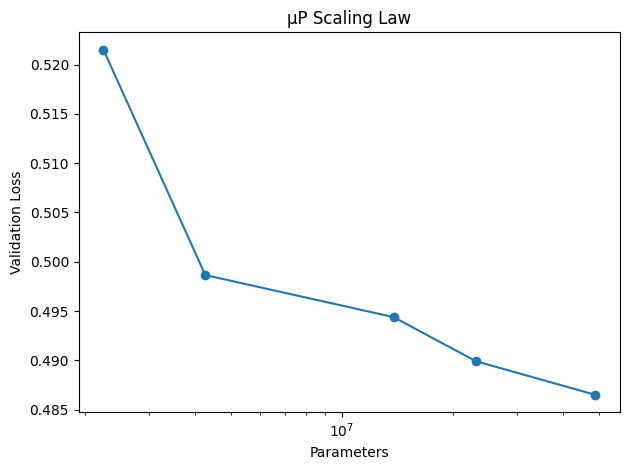

In [ ]:
plt.figure()
plt.xscale("log")
plt.plot(params_list, losses_list, "o-")
plt.xlabel("Parameters")
plt.ylabel("Validation Loss")
plt.title("µP Scaling Law")
plt.tight_layout()
plt.show()

In [ ]:
def power_law(N, a, alpha, c):
    return a * (N ** (-alpha)) + c

params_np = np.array(params_list, dtype=float)
loss_np   = np.array(losses_list, dtype=float)

try:
    popt, pcov = curve_fit(
        power_law, params_np, loss_np,
        p0=[1.0, 0.05, 0.4],
        maxfev=50000
    )
    a, alpha, c = popt
    print(f"\nPower-law fit:  a={a:.4f}, alpha={alpha:.4f}, c={c:.4f}")

    N_new     = 10 * max(params_np)
    pred      = power_law(N_new, *popt)
    residuals = loss_np - power_law(params_np, *popt)
    sigma     = np.std(residuals)
    print(f"Predicted loss (10x XL = {N_new/1e6:.0f}M params): {pred:.4f} ± {sigma:.4f}")

except Exception as e:
    print("curve_fit failed:", e)
    print("Falling back to log-linear fit...")

    # fallback: fit log(L) = slope * log(N) + intercept
    logN   = np.log(params_np)
    logL   = np.log(loss_np)
    coeffs = np.polyfit(logN, logL, 1)
    alpha  = -coeffs[0]
    print(f"Log-linear alpha: {alpha:.4f}")

    N_pred    = 10 * max(params_np)
    logL_pred = np.polyval(coeffs, np.log(N_pred))
    L_pred    = np.exp(logL_pred)
    print(f"Predicted loss (10x XL): {L_pred:.4f}")



Power-law fit:  a=3234318901.2438, alpha=1.7323, c=0.4893
Predicted loss (10x XL = 489M params): 0.4893 ± 0.0022


Part 3 = µP study. Here you fix layers and vary only width, because µP requires a fixed computational graph. That constraint lives in Part 3, not Part 2.

In [ ]:
# Save aggregated results
import json, os

save_dir = base_path + "/Part3WithBetterMuRERUN"
os.makedirs(save_dir, exist_ok=True)

torch.save(results_mup, save_dir + "/mup_scaling_results.pt")
torch.save(results_mup_lr, save_dir + "/mup_lr_sweep.pt")

# Save plots (recreate + save if needed)
plt.figure()
plt.xscale("log")
plt.plot(params_list, losses_list, "o-")
plt.xlabel("Parameters")
plt.ylabel("Validation Loss")
plt.title("µP Scaling Law")
plt.tight_layout()
plt.savefig(save_dir + "/mup_scaling_law.png")
plt.close()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/Colab Notebooks/ML"

Mounted at /content/drive


In [ ]:


import torch
import matplotlib.pyplot as plt
import numpy as np

base_path = "/content/drive/MyDrive/Colab Notebooks/ML"
save_dir = base_path + "/Part3WithBetterMuRERUN"

# Load the saved results
results_mup = torch.load(save_dir + "/mup_scaling_results.pt")
results_mup_lr = torch.load(save_dir + "/mup_lr_sweep.pt")

print("Loaded keys in results_mup:", list(results_mup.keys()))
print("Loaded keys in results_mup_lr:", list(results_mup_lr.keys()))

Loaded keys in results_mup: ['tiny', 'small', 'medium', 'large', 'xl']
Loaded keys in results_mup_lr: [1e-05, 3e-05, 0.0001, 0.0003, 0.001, 0.003, 0.005]


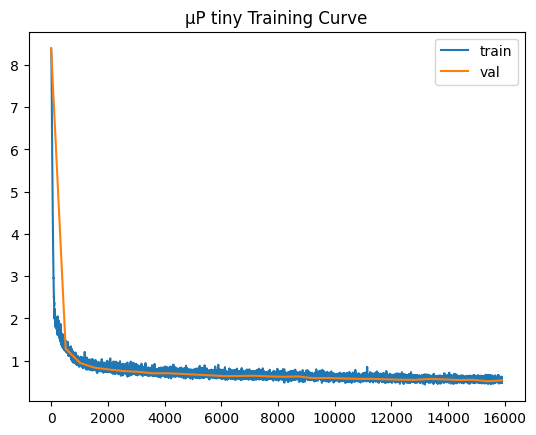

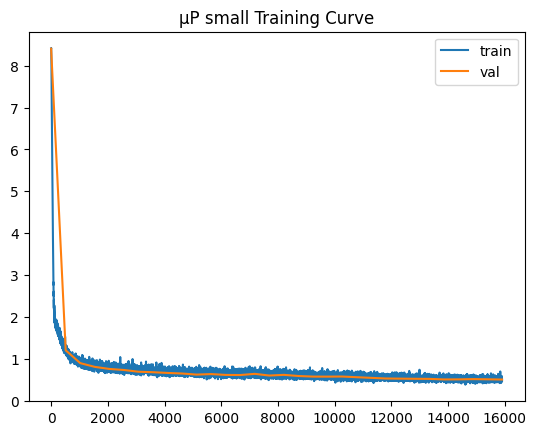

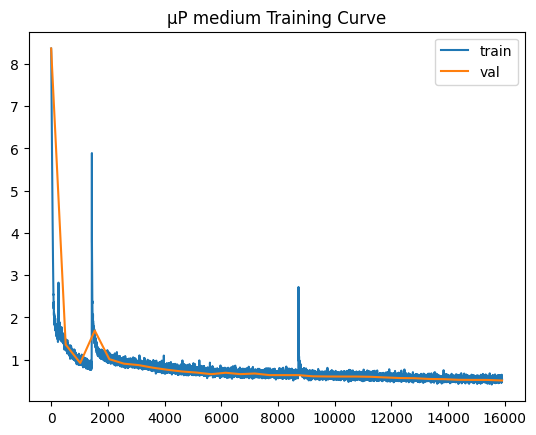

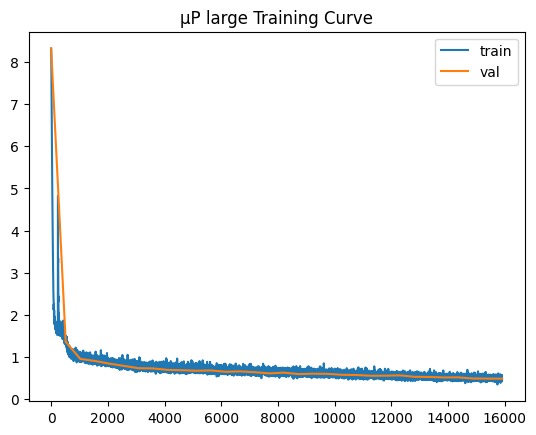

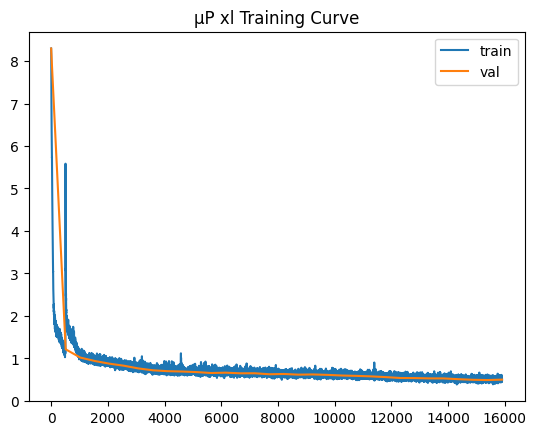

In [ ]:
# Validation loss vs step — one plot per model (like Part 2)
for name, res in results_mup.items():
    res = results_mup[name]

    plt.figure()
    plt.plot(res["train_losses"], label="train")

    val_x = np.linspace(0, len(res["train_losses"]), len(res["val_losses"]))
    plt.plot(val_x, res["val_losses"], label="val")

    plt.title(f"µP {name} Training Curve")
    plt.legend()
    plt.show()